<a href="https://colab.research.google.com/github/RafaAAbreu/data-analysis-dashboard/blob/main/Analise_Vendas_Fast_Food.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


EDA - ANÁLISE EXPLORATÓRIA DE DADOS


O EDA (Exploratory Data Analysis) entendendo os dados antes da criação de modelos ou dashboards.

Objetivo:
- conhecer a estrutura da base
- encontrar erros
- identificar padrões
- detectar valores ausentes
- descobrir possíveis insights

In [2]:
# carregar dados
df = pd.read_excel("Vendas Fast-Food.xlsx")

In [3]:
# VISUALIZAÇÃO INICIAL

print("Primeiras linhas:")
display(df.head())

print("Últimas linhas:")
display(df.tail())

Primeiras linhas:


,Pedido,Unidade,Canal,Categoria,Valor Total,Tempo Preparo (min),Status
0,2001,Bairro Oeste,App Delivery,Hambúrguer,80.93,5,Entregue
1,2002,Expresso Leste,App Delivery,Combo,114.57,38,Cancelado
2,2003,Drive-thru Sul,Drive-thru,Hambúrguer,85.91,33,Entregue
3,2004,Expresso Leste,Balcão,Acompanhamento,19.41,17,Entregue
4,2005,Expresso Leste,App Delivery,Bebida,132.25,33,Atrasado


Últimas linhas:


,Pedido,Unidade,Canal,Categoria,Valor Total,Tempo Preparo (min),Status
995,2996,Shopping Norte,Drive-thru,Sobremesa,70.60,8,Entregue
996,2997,Centro,Balcão,Sobremesa,116.74,23,Entregue
997,2998,Centro,Balcão,Acompanhamento,42.50,30,Atrasado
998,2999,Bairro Oeste,Balcão,Sobremesa,59.22,15,Atrasado
999,3000,Drive-thru Sul,Balcão,Bebida,88.80,44,Entregue


In [4]:
# TAMANHO DA BASE

linhas,colunas=df.shape

print(f"Quantidade de linhas: {linhas}")
print(f"Quantidade de colunas: {colunas}")

Quantidade de linhas: 1000
Quantidade de colunas: 7


In [5]:
# ESTRUTURA DOS DADOS

# tipos
# valores nulos
# memória utilizada

print("Estrutura da base:")
df.info()


Estrutura da base:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Pedido               1000 non-null   int64  
 1   Unidade              1000 non-null   object 
 2   Canal                1000 non-null   object 
 3   Categoria            1000 non-null   object 
 4   Valor Total          1000 non-null   float64
 5   Tempo Preparo (min)  1000 non-null   int64  
 6   Status               1000 non-null   object 
dtypes: float64(1), int64(2), object(4)
memory usage: 54.8+ KB


In [6]:
# ESTATÍSTICAS DESCRITIVAS

# média
# mínimo
# máximo
# quartis

print("Resumo estatístico:")

display(df.describe())

Resumo estatístico:


,Pedido,Valor Total,Tempo Preparo (min)
count,1000.000000,1000.000000,1000.000000
mean,2500.500000,83.897550,24.587000
std,288.819436,38.718452,11.353649
min,2001.000000,15.060000,5.000000
25%,2250.750000,51.060000,15.000000
50%,2500.500000,85.725000,24.000000
75%,2750.250000,117.727500,34.000000
max,3000.000000,149.960000,44.000000


In [7]:
# VERIFICAR DADOS VAZIOS


print("Valores nulos por coluna:")

nulos=df.isnull().sum()

display(nulos)


Valores nulos por coluna:


,0
Pedido,0
Unidade,0
Canal,0
Categoria,0
Valor Total,0
Tempo Preparo (min),0
Status,0


In [8]:
# VER DADOS DUPLICADOS

duplicados=df.duplicated().sum()

print("Registros duplicados encontrados: {duplicados}")

Registros duplicados encontrados: 0


---

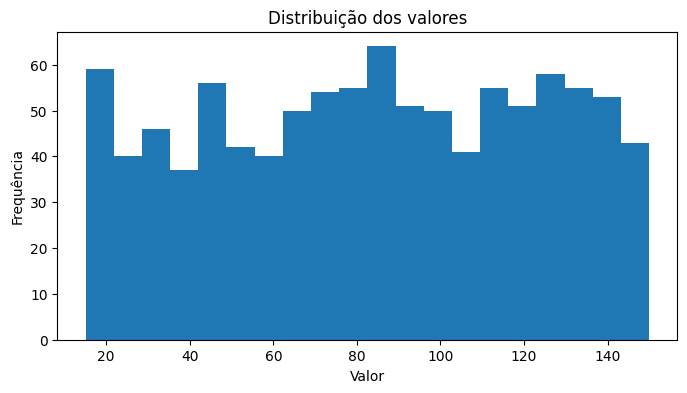

In [9]:
# DISTRIBUIÇÃO DOS VALORES


plt.figure(
    figsize=(8,4)
)

plt.hist(
    df["Valor Total"],
    bins=20
)

plt.title(
    "Distribuição dos valores"
)

plt.xlabel(
    "Valor"
)

plt.ylabel(
    "Frequência"
)

plt.show()


---

In [10]:
df_categoria_qtd = df['Categoria'].value_counts().reset_index()
df_categoria_qtd.columns=["Categoria","Quantidade"]
df_categoria_qtd

,Categoria,Quantidade
0,Acompanhamento,224
1,Sobremesa,202
2,Hambúrguer,197
3,Combo,194
4,Bebida,183


---

In [11]:
df_Valor_Total = df.groupby("Canal")["Valor Total"].sum().reset_index()
df_Valor_Total.sort_values("Valor Total",ascending=False,inplace=True)
df_Valor_Total

,Canal,Valor Total
0,App Delivery,28934.74
1,Balcão,27908.66
2,Drive-thru,27054.15


In [12]:
df_categoria = df.groupby("Categoria")["Valor Total"].sum().reset_index()
df_categoria.sort_values("Valor Total",ascending=False,inplace=True)
df_categoria



,Categoria,Valor Total
0,Acompanhamento,18588.11
4,Sobremesa,17171.17
3,Hambúrguer,16923.89
2,Combo,16220.50
1,Bebida,14993.88


---

# CONCLUSÕES

Principais insights encontrados:


- App Delivery apresentou maior faturamento

- Acompanhamentos apresentou maior volume de pedidos

- Tempos de preparo permaneceram próximos do esperado

- Os canais apresentaram tempos médios de preparo semelhantes, indicando estabilidade operacional.


---

In [13]:
df.head()

,Pedido,Unidade,Canal,Categoria,Valor Total,Tempo Preparo (min),Status
0,2001,Bairro Oeste,App Delivery,Hambúrguer,80.93,5,Entregue
1,2002,Expresso Leste,App Delivery,Combo,114.57,38,Cancelado
2,2003,Drive-thru Sul,Drive-thru,Hambúrguer,85.91,33,Entregue
3,2004,Expresso Leste,Balcão,Acompanhamento,19.41,17,Entregue
4,2005,Expresso Leste,App Delivery,Bebida,132.25,33,Atrasado


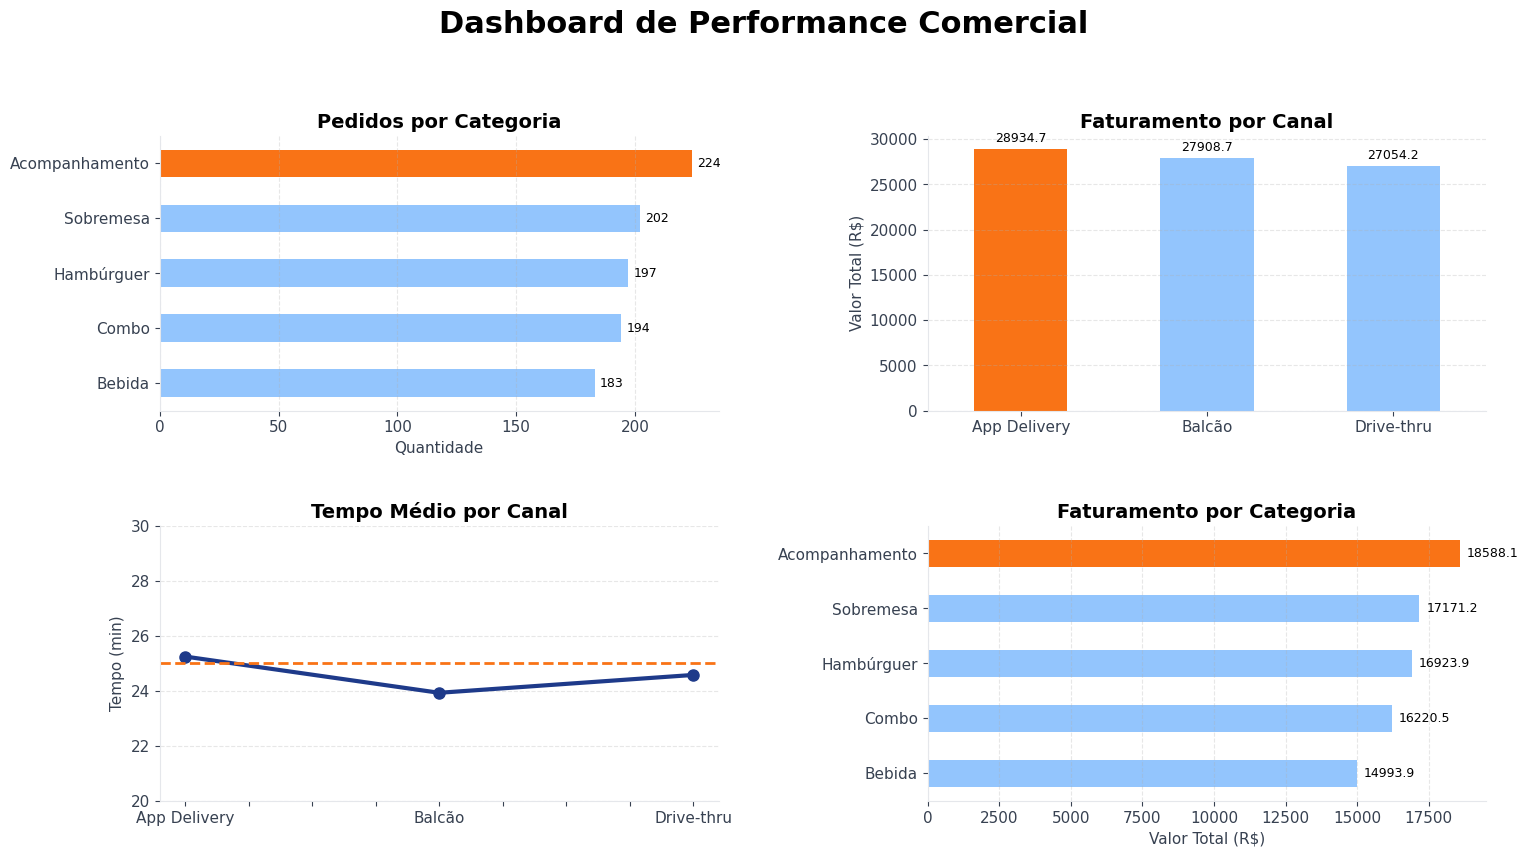

In [14]:
# PALETA DE CORES

AZUL_PRINCIPAL = "#2563EB"
AZUL_CLARO = "#93C5FD"
AZUL_ESCURO = "#1E3A8A"

LARANJA = "#F97316"

CINZA_CLARO = "#E5E7EB"
FUNDO = "#FFFFFF"

# ESTILO GLOBAL

plt.style.use("default")

plt.rcParams.update({
    "figure.facecolor": FUNDO,
    "axes.facecolor": FUNDO,
    "axes.edgecolor": CINZA_CLARO,
    "axes.labelcolor": "#374151",
    "xtick.color": "#374151",
    "ytick.color": "#374151",
    "font.size": 11,
    "axes.titleweight":"bold",
    "axes.titlesize":14
})

plt.rcParams['savefig.facecolor']='#FFFFFF'

# ORDENAR DADOS

df_categoria_qtd = (df_categoria_qtd.sort_values(by="Quantidade",ascending=True))

df_categoria = (df_categoria.sort_values(by="Valor Total",ascending=True))

df_canal = df.groupby("Canal")["Tempo Preparo (min)"].mean().reset_index()


# FIGURA

fig, ax = plt.subplots(
    nrows=2,
    ncols=2,
    figsize=(16,9)
)

fig.patch.set_facecolor("#FFFFFF")

for eixo in ax.flatten():
    eixo.set_facecolor("#FFFFFF")

# TÍTULO PRINCIPAL

plt.suptitle(
    "Dashboard de Performance Comercial",
    fontsize=22,
    fontweight='bold',
    y=0.98
)

# PEDIDOS POR CATEGORIA

cores_qtd = [
    AZUL_CLARO,
    AZUL_CLARO,
    AZUL_CLARO,
    AZUL_CLARO,
    LARANJA
]

ax1 = df_categoria_qtd.plot(
    kind="barh",
    x="Categoria",
    y="Quantidade",
    legend=False,
    color=cores_qtd,
    ax=ax[0,0]
)

ax1.set_title("Pedidos por Categoria")

ax1.set_xlabel("Quantidade")
ax1.set_ylabel("")

ax1.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

for container in ax1.containers:
    ax1.bar_label(
        container,
        padding=4,
        fontsize=9
    )

ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# FATURAMENTO POR CANAL

cores_canal=[

    LARANJA,
    AZUL_CLARO,
    AZUL_CLARO
]

ax2=df_Valor_Total.plot(
    kind="bar",
    x="Canal",
    y="Valor Total",
    legend=False,
    color=cores_canal,
    ax=ax[0,1]
)

ax2.set_title(
    "Faturamento por Canal"
)

ax2.set_ylabel(
    "Valor Total (R$)"
)

ax2.set_xlabel("")

ax2.tick_params(
    axis="x",
    rotation=0
)

ax2.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

for container in ax2.containers:
    ax2.bar_label(
        container,
        padding=3,
        fontsize=9
    )

ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

# TEMPO MÉDIO POR CANAL

ax3=df_canal.plot(
    kind="line",
    x="Canal",
    y="Tempo Preparo (min)",
    legend=False,
    color=AZUL_ESCURO,
    linewidth=3,
    marker="o",
    markersize=8,

    ax=ax[1,0]
)

ax3.set_title(
    "Tempo Médio por Canal"
)

ax3.set_ylabel(
    "Tempo (min)"
)

ax3.set_xlabel("")

ax3.set_ylim(
    20,
    30
)

ax3.axhline(
    y=25,
    color=LARANJA,
    linestyle="--",
    linewidth=2
)

ax3.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax3.spines["top"].set_visible(False)
ax3.spines["right"].set_visible(False)

# FATURAMENTO POR CATEGORIA

cores_categoria=[

    AZUL_CLARO,
    AZUL_CLARO,
    AZUL_CLARO,
    AZUL_CLARO,
    LARANJA
]

ax4=df_categoria.plot(
    kind="barh",
    x="Categoria",
    y="Valor Total",
    legend=False,
    color=cores_categoria,
    ax=ax[1,1]
)

ax4.set_title(
    "Faturamento por Categoria"
)

ax4.set_xlabel(
    "Valor Total (R$)"
)

ax4.set_ylabel("")

ax4.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

for container in ax4.containers:
    ax4.bar_label(
        container,
        padding=5,
        fontsize=9
    )

ax4.spines["top"].set_visible(False)
ax4.spines["right"].set_visible(False)



plt.tight_layout(
    pad=3
)

plt.show()